# Phi Scale Analysis: Analytical vs ML $R_{GL}$

This notebook:
1. Loads pre-computed analytical $R_{GL}$ data from `ratio_ploter.py` output
2. Recreates the $R_{GL}$ vs $\phi_{\mathrm{scale}}$ plot
3. Trains a `TaskSpecificHeads` model (local shape) at each $\phi_{\mathrm{scale}}$
4. Computes $R_{GL}^{ML} = \sigma_{Fisher} / \text{RMSE}_{ML}$ and overlays on the analytical curve

Models are saved to disk so incomplete runs can be resumed.

In [4]:
import gc
import os
import sys
import math
import time
import logging
from datetime import datetime

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
sys.path.append("/users/stevensonb/Research/tools/deepsphere-cosmo-tf2")

import tensorflow as tf

tf.get_logger().setLevel(logging.ERROR)

# Enable GPU memory growth
gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(f"GPU memory growth error: {e}")

import h5py
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dense, Dropout, Flatten, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping, TerminateOnNaN
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.optimizers.schedules import CosineDecayRestarts, ExponentialDecay
from tensorflow.keras.models import load_model

from deepsphere import HealpyGCNN
from deepsphere.healpy_layers import HealpyChebyshev, HealpyPool

from mlpng import Core
from mlpng.utils import setup_logging, rmse_metrics, get_data, save_data
from mlpng.utils.dataloaders import KappaDataset

setup_logging("mlpng.notebook", level=logging.DEBUG)
logger = logging.getLogger("mlpng.notebook")

# Distributed strategy for multi-GPU
strategy = tf.distribute.MirroredStrategy()
print(f"Using {strategy.num_replicas_in_sync} device(s)")

Using 1 device(s)


In [6]:
# =============================================================================
# Configuration — set all parameters here
# =============================================================================

# Core initialization (n256, local shape, T polarization, lensing enabled)
core = Core(
    [
        "./settings/n256.json",
        "--shapes",
        "local",
        "--nsims",
        "10000",
        "--pols",
        "T",
        "--lensing",
    ]
)

# Training hyperparameters (from trainer.ipynb)
DATA_FRACTION = 0.1
DUPLICATES = [10, 10, 2]  # Train, val, test duplication
MAX_EPOCHS = 30
PATIENCE = 8
BATCH_SIZE = 128
DECAY_STEPS = core.total_sims * 0.8 * DATA_FRACTION // BATCH_SIZE

# Model hyperparameters (from trainer.ipynb)
MODEL_TYPE = "task"
POOL_P = 2
K = 5
ENCODER_ACTIVATION = "gelu"
HEAD_ACTIVATION = "gelu"
POOL_TYPE = "AVG"
DROPOUT_RATE = 0.05
HEAD_DROPOUT = 0.1

# Optimizer settings
use_cosine_decay = False
initial_lr = 1e-4
decay_rate = 0.96
weight_decay = 1e-5

# Phi scales to train ML models at (subset of ratio_ploter PHI_SCALES)
PHI_SCALES_ML = [1, 5, 10, 50, 100, 200, 500]

# Paths
DATA_FILE = core.file  # nsims=10000 for ML training
# ratio_ploter was run with nsims=100, so its output is in a different file
RATIO_DATA_FILE = DATA_FILE.replace("10000", "100")
MODEL_DIR = os.path.join(core.dirs["model"], "phi_scale_analysis")
os.makedirs(MODEL_DIR, exist_ok=True)

# Cache directory
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
CACHE_DIR = f"/lustre/smuexa01/client/users/stevensonb/tf_cache/"
os.makedirs(CACHE_DIR, exist_ok=True)

# Fisher sigma values
sigma_fisher_unlensed = core.get_likelihoods(False)[0]
print(f"Data file (ML):    {DATA_FILE}")
print(f"Data file (ratio): {RATIO_DATA_FILE}")
print(f"Model dir: {MODEL_DIR}")
print(f"nside={core.nside}, lmax={core.lmax}, npix={core.npix}, npol={core.npols}")
print(f"shapes={core.shapes}")
print(f"σ_Fisher (unlensed) = {sigma_fisher_unlensed:.4f}")
print(f"σ_Fisher (lensed)   = {sigma_fisher_lensed:.4f}")

print(f"PHI_SCALES_ML = {PHI_SCALES_ML}")
print(f"σ_Fisher (lensed)   = {sigma_fisher_lensed:.4f}")
print(f"PHI_SCALES_ML = {PHI_SCALES_ML}")

23-Feb-26 10:35:42 - mlpng.core - DEBUG - Parsing CLI args: ['./settings/n256.json', '--shapes', 'local', '--nsims', '10000', '--pols', 'T', '--lensing']
23-Feb-26 10:35:42 - mlpng.core - INFO - Loading settings from file './settings/n256.json'
23-Feb-26 10:35:42 - mlpng.core - DEBUG - Forcing setting 'nsims' to 10000 due to CLI
23-Feb-26 10:35:42 - mlpng.core - DEBUG - Forcing setting 'pols' to T due to CLI
23-Feb-26 10:35:42 - mlpng.core - DEBUG - Forcing setting 'shapes' to ['local'] due to CLI
23-Feb-26 10:35:42 - mlpng.core - DEBUG - Forcing setting 'lensing' to True due to CLI
23-Feb-26 10:35:42 - mlpng.core - DEBUG - Forcing setting 'tf_cache' to True due to CLI
23-Feb-26 10:35:42 - mlpng.core - DEBUG - Forcing setting 'tf_mem_cache' to True due to CLI
23-Feb-26 10:35:42 - mlpng.core - DEBUG - Overriding cosmo param 'As' from 2.13e-09 to 2.105e-09
23-Feb-26 10:35:42 - mlpng.core - DEBUG - Overriding cosmo param 'ns' from 0.9624 to 0.965
23-Feb-26 10:35:42 - mlpng.core - DEBUG - 

## Load Analytical $R_{GL}$ Data

Load the pre-computed $R_{GL}$ values from `ratio_ploter.py` output stored in the HDF5 data file under the `"ratio_plot"` group. If the data doesn't exist, you need to run:

```bash
python -m mlpng.ratio_ploter settings/n256.json --pols T --shapes local --lensing
```

In [7]:
# Load analytical R_GL data from ratio_ploter output (nsims=100 file)
try:
    with h5py.File(RATIO_DATA_FILE, "r") as f:
        rp = f["ratio_plot"]
        phi_scales_analytical = rp["phi_scales"][:]
        R_gl_analytical = rp["R_gl"][:]
        N2_0 = float(rp["N2_0"][0])
        N2_lens = float(rp["N2_lens"][0])
        delta_N2_analytical = rp["delta_N2"][:]
        lmax_rp = int(rp["lmax"][0])

    print(f"Loaded analytical R_GL data from {RATIO_DATA_FILE} (lmax={lmax_rp})")
    print(f"  phi_scales: {phi_scales_analytical}")
    print(f"  R_GL:       {np.round(R_gl_analytical, 4)}")
    print(f"  N2_0 = {N2_0:.6e}")
    print(f"  N2_lens = {N2_lens:.6e}")

except (FileNotFoundError, KeyError) as e:
    raise RuntimeError(
        f"Analytical R_GL data not found in {RATIO_DATA_FILE}.\n"
        "Run `python -m mlpng.ratio_ploter settings/n256.json --pols T --shapes local --lensing` first."
    ) from e

Loaded analytical R_GL data from data/data/l767_n256_T_100_p1.0.hdf5 (lmax=767)
  phi_scales: [  1.   2.   3.   4.   5.  10.  20.  50. 100. 150. 200. 250. 300. 400.
 500.]
  R_GL:       [0.9972 0.9893 0.9767 0.9598 0.9395 0.8078 0.5657 0.265  0.1361 0.0911
 0.0683 0.0548 0.0457 0.0344 0.0275]
  N2_0 = 2.535894e-03
  N2_lens = 2.536896e-03


23-Feb-26 10:35:42 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
23-Feb-26 10:35:42 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
23-Feb-26 10:35:42 - matplotlib.font_manager - DEBUG - findfont: Matching serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
23-Feb-26 10:35:42 - matplotlib.font_manager - DEBUG - findfont: score(FontEntry(fname='/users/stevensonb/.conda/envs/ds25/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/STIXNonUniBolIta.ttf', name='STIXNonUnicode', style='italic', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.335
23-Feb-26 10:35:42 - matplotlib.font_manager - DEBUG - findfont: score(FontEntry(fname='/users/stevensonb/.conda/envs/ds25/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizOneSymBol.ttf', name='STIXSizeOneSym', style='normal', variant='normal', weight=700, stretch='norm

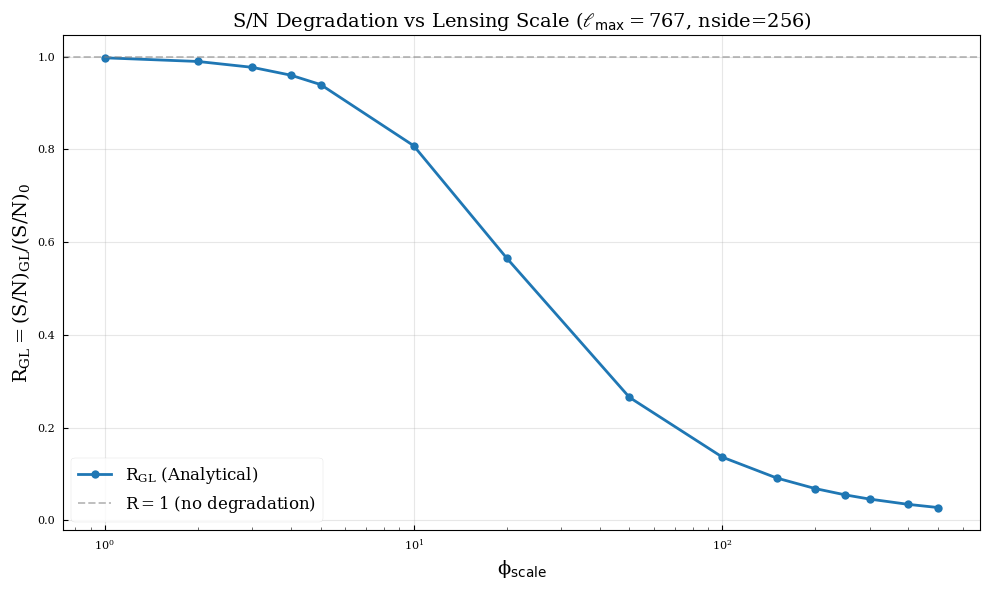

In [8]:
# Recreate the ratio_ploter plot: R_GL vs phi_scale
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    phi_scales_analytical,
    R_gl_analytical,
    "o-",
    color="tab:blue",
    linewidth=2,
    markersize=6,
    label=r"$R_{GL}$ (Analytical)",
)
ax.axhline(
    y=1.0, color="gray", linestyle="--", alpha=0.5, label=r"$R=1$ (no degradation)"
)

ax.set_xlabel(r"$\phi_{\mathrm{scale}}$", fontsize=14)
ax.set_ylabel(r"$R_{GL} = (S/N)_{GL} / (S/N)_0$", fontsize=14)
ax.set_title(
    rf"S/N Degradation vs Lensing Scale ($\ell_{{\max}}={core.lmax}$, nside={core.nside})",
    fontsize=14,
)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_xscale("log")

plt.tight_layout()
plt.show()

## Model Architecture

Encoder-based model with `TaskSpecificHeads` for the local shape, following `trainer.ipynb`. The encoder uses HEALPix Chebyshev graph convolutions with pooling, followed by a shape-specific prediction head.

In [9]:
class EncoderBlock(tf.keras.layers.Layer):
    """Encoder block with HEALPix Chebyshev convolution and pooling."""

    def __init__(
        self,
        nside,
        npix,
        fin,
        fout,
        K,
        pool_p,
        max_batch_size,
        dropout_rate=0.1,
        activation="gelu",
        pool_type="AVG",
        **kwargs
    ):
        super().__init__(**kwargs)
        self.nside = nside
        initializer = (
            tf.keras.initializers.HeNormal()
            if activation == "relu"
            else tf.keras.initializers.GlorotNormal()
        )
        layers = [
            HealpyChebyshev(
                K=K,
                Fout=fout,
                activation=activation,
                use_bn=True,
                use_bias=True,
                initializer=initializer,
            ),
            Dropout(dropout_rate),
            HealpyPool(pool_p, pool_type),
        ]
        self.body = HealpyGCNN(
            nside=nside,
            indices=np.arange(npix),
            layers=layers,
            n_neighbors=8,
            max_batch_size=max_batch_size,
            initial_Fin=fin,
        )

    def call(self, x, training=False):
        return self.body(x, training=training)


class TaskSpecificHeads(tf.keras.layers.Layer):
    """Shape-dependent heads with increasing capacity for local, equilateral, orthogonal."""

    SHAPE_TO_HEAD_INDEX = {"local": 0, "equilateral": 1, "orthogonal": 2}
    HEAD_ARCHITECTURES = {
        0: [64, 32, 32, 1],  # local: simple
        1: [32, 128, 256, 256, 64, 32, 1],  # equilateral: complex
        2: [16, 64, 64, 32, 32, 1],  # orthogonal: medium
    }

    def __init__(self, n_outputs, task_names, activation="relu", dropout=0.0, **kwargs):
        super().__init__(**kwargs)
        self.n_outputs = n_outputs
        self.task_names = (
            task_names if isinstance(task_names, (list, tuple)) else [task_names]
        )
        self.activation = activation

        init = (
            tf.keras.initializers.HeNormal()
            if activation == "relu"
            else tf.keras.initializers.GlorotNormal()
        )

        def build_head(sizes, prefix, head_dropout=0.0, head_activation=None):
            layers = []
            if head_dropout > 0:
                layers.append(Dropout(head_dropout, name=f"{prefix}_dropout_0"))
            act = head_activation or activation
            for i, size in enumerate(sizes[:-1]):
                layers.append(
                    Dense(
                        size,
                        activation=act,
                        kernel_initializer=init,
                        name=f"{prefix}_dense_{i+1}",
                    )
                )
            layers.append(
                Dense(sizes[-1], kernel_initializer=init, name=f"{prefix}_output")
            )
            return layers

        self.heads = {}
        for shape_name in self.task_names:
            if shape_name in self.SHAPE_TO_HEAD_INDEX:
                head_idx = self.SHAPE_TO_HEAD_INDEX[shape_name]
                head_arch = self.HEAD_ARCHITECTURES[head_idx]
                self.heads[shape_name] = build_head(
                    head_arch, f"head_{shape_name}", dropout, activation
                )

    def call(self, x, training=False):
        outputs = []
        for shape_name in self.task_names:
            if shape_name in self.heads:
                out = x
                for layer in self.heads[shape_name]:
                    out = (
                        layer(out, training=training)
                        if isinstance(layer, Dropout)
                        else layer(out)
                    )
                outputs.append(out)
        return (
            tf.keras.layers.Concatenate()(outputs) if len(outputs) > 1 else outputs[0]
        )


def build_task_model(
    nside,
    npix,
    npol,
    n_outputs,
    task_names,
    max_batch_size=128,
    pool_p=2,
    K=7,
    encoder_activation="gelu",
    head_activation="gelu",
    pool_type="AVG",
    dropout_rate=0.1,
    head_dropout=0.05,
):
    """Build encoder with task-specific heads."""
    nside_factor = 2**pool_p
    depth = int(math.log(nside, nside_factor))
    level_nsides = [nside // (nside_factor**i) for i in range(depth + 1)]
    level_npixels = [12 * ns**2 for ns in level_nsides]
    channels = [npol] + [2 ** (i + 5) for i in range(depth + 1)]

    inputs = tf.keras.Input(shape=(npix, npol), name="lensed_maps")
    x = inputs
    for i in range(depth):
        x = EncoderBlock(
            nside=level_nsides[i],
            npix=level_npixels[i],
            fin=channels[i],
            fout=channels[i + 1],
            K=K,
            pool_p=pool_p,
            max_batch_size=max_batch_size,
            dropout_rate=dropout_rate,
            activation=encoder_activation,
            pool_type=pool_type,
        )(x)
    x = Flatten()(x)
    outputs = TaskSpecificHeads(n_outputs, task_names, head_activation, head_dropout)(x)
    return tf.keras.Model(inputs, outputs, name="task_conditioned_encoder")


# Quick test: verify model builds correctly
test_model = build_task_model(
    nside=core.nside,
    npix=core.npix,
    npol=core.npols,
    n_outputs=len(core.shapes),
    task_names=core.shapes,
    max_batch_size=BATCH_SIZE,
    pool_p=POOL_P,
    K=K,
    encoder_activation=ENCODER_ACTIVATION,
    head_activation=HEAD_ACTIVATION,
    pool_type=POOL_TYPE,
    dropout_rate=DROPOUT_RATE,
    head_dropout=HEAD_DROPOUT,
)
test_model.summary()
del test_model

Model: "task_conditioned_encoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lensed_maps (InputLayer)    [(None, 786432, 1)]       0         
                                                                 
 encoder_block (EncoderBloc  (None, 49152, 32)         256       
 k)                                                              
                                                                 
 encoder_block_1 (EncoderBl  (None, 3072, 64)          10432     
 ock)                                                            
                                                                 
 encoder_block_2 (EncoderBl  (None, 192, 128)          41344     
 ock)                                                            
                                                                 
 encoder_block_3 (EncoderBl  (None, 12, 256)           164608    
 ock)                                     

## Helper Functions

Dataset creation, model training, evaluation, and checkpoint/resume utilities.

In [ ]:
def create_dataset(phi_scale, cache_suffix=""):
    """Create train/val/test datasets for a given phi_scale."""
    ds = KappaDataset.fromCore(
        core, phi_scale=float(phi_scale), x_output="lensed", y_output="fnl"
    )
    train_ds, val_ds, test_ds = ds.split(
        train_size=0.8 * DATA_FRACTION,
        val_size=0.1 * DATA_FRACTION,
        test_size=0.1 * DATA_FRACTION,
        to_tf=True,
        batch_size=BATCH_SIZE,
        duplicates=DUPLICATES,
        gen_batch_size=8,
        cache_dir=CACHE_DIR,
        cache_file=f"phi-analysis-n{core.nside}{cache_suffix}",
    )
    return train_ds, val_ds, test_ds


def train_model(model, train_ds, val_ds, model_name="model"):
    """Compile and train a model, returning (history, train_time)."""
    if use_cosine_decay:
        lr_schedule = CosineDecayRestarts(
            initial_lr, DECAY_STEPS, t_mul=2.0, m_mul=0.95, alpha=0.01
        )
    else:
        lr_schedule = ExponentialDecay(
            initial_lr, DECAY_STEPS, decay_rate, staircase=True
        )

    with strategy.scope():
        model.compile(
            optimizer=AdamW(learning_rate=lr_schedule, weight_decay=weight_decay),
            loss="mse",
            metrics=rmse_metrics(core.shapes),
        )

    callbacks = [
        TerminateOnNaN(),
        EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True),
    ]

    start = time.time()
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=MAX_EPOCHS,
        callbacks=callbacks,
        verbose=1,
    )
    train_time = time.time() - start
    return history, train_time


def evaluate_model(model, test_ds):
    """Evaluate model on test set, returning (predictions, truth, rmse)."""
    preds = model.predict(test_ds, verbose=0)
    truth = np.concatenate([y.numpy() for _, y in test_ds])

    # Flatten for single-shape output
    if len(core.shapes) == 1:
        truth = truth.ravel()
        preds = preds.ravel()

    rmse = np.sqrt(np.mean((preds - truth) ** 2))
    return preds, truth, rmse


def load_or_train(model_path, build_fn, train_ds, val_ds, model_name="model"):
    """Load existing model or train a new one. Supports resuming incomplete runs."""
    if os.path.exists(model_path):
        print(f"  Loading existing model from {model_path}")
        with strategy.scope():
            model = load_model(model_path)
        gc.collect()
        tf.keras.backend.clear_session()
        return model, None, 0

    print(f"  Training new model: {model_name}")
    with strategy.scope():
        model = build_fn()
    history, train_time = train_model(model, train_ds, val_ds, model_name=model_name)
    model.save(model_path)
    print(f"  Model saved to {model_path}")
    gc.collect()
    return model, history, train_time


print("Helper functions defined.")

Helper functions defined.


: 

## Train Models at Each $\phi_{\mathrm{scale}}$

Train a dedicated `TaskSpecificHeads` model for each phi_scale in `PHI_SCALES_ML`. Models are saved to disk and will be loaded automatically if they already exist, allowing incomplete runs to be resumed.

In [11]:
# Training loop over phi_scales with checkpoint/resume support
results = {}

for phi_scale in PHI_SCALES_ML:
    print(f"\n{'='*60}")
    print(f"Processing phi_scale = {phi_scale}")
    print(f"{'='*60}")

    model_path = os.path.join(MODEL_DIR, f"task-phi{phi_scale}.keras")

    # Build model factory
    def build_fn(ps=phi_scale):
        return build_task_model(
            nside=core.nside,
            npix=core.npix,
            npol=core.npols,
            n_outputs=len(core.shapes),
            task_names=core.shapes,
            max_batch_size=BATCH_SIZE,
            pool_p=POOL_P,
            K=K,
            encoder_activation=ENCODER_ACTIVATION,
            head_activation=HEAD_ACTIVATION,
            pool_type=POOL_TYPE,
            dropout_rate=DROPOUT_RATE,
            head_dropout=HEAD_DROPOUT,
        )

    # Create dataset for this phi_scale
    train_ds, val_ds, test_ds = create_dataset(
        phi_scale, cache_suffix=f"-phi{phi_scale}"
    )

    # Load or train model
    model, history, train_time = load_or_train(
        model_path,
        build_fn,
        train_ds,
        val_ds,
        model_name=f"task-phi{phi_scale}",
    )

    # Evaluate on test set
    preds, truth, rmse = evaluate_model(model, test_ds)
    R_gl_ml = sigma_fisher_unlensed / rmse

    results[phi_scale] = {
        "rmse": rmse,
        "R_gl_ml": R_gl_ml,
        "history": history,
        "train_time": train_time,
        "preds": preds,
        "truth": truth,
    }

    print(f"  RMSE = {rmse:.4f}")
    print(f"  σ_Fisher (unlensed) / RMSE = R_GL_ML = {R_gl_ml:.4f}")
    print(f"  Train time = {train_time:.1f}s")

    # Clean up to manage GPU memory
    del model
    gc.collect()
    tf.keras.backend.clear_session()

print(f"\n{'='*60}")
print("All phi_scales processed!")
print(f"{'='*60}")


Processing phi_scale = 1
23-Feb-26 10:40:20 - mlpng.utils.dataloaders - DEBUG - Error information from 'data/data/l767_n256_T_10000_p1.0.hdf5'...
23-Feb-26 10:40:20 - mlpng.utils.dataloaders - DEBUG - Fisher Matrix: [0.00872105 0.02665056 0.07709787]
23-Feb-26 10:40:20 - mlpng.utils.dataloaders - DEBUG - Marginal Likelihoods: 10.71128
23-Feb-26 10:40:20 - mlpng.utils.dataloaders - DEBUG - Fisher for shape local: 0.008502264, std div: 10.845078637039325
23-Feb-26 10:40:20 - mlpng.utils.dataloaders - DEBUG - Splitting 'data/data/l767_n256_T_10000_p1.0.hdf5' into train: 0:800 (800), val: 800:900 (100), test: 900:1000 (100)
23-Feb-26 10:40:20 - mlpng.utils.dataloaders - DEBUG - Using cache file: '/lustre/smuexa01/client/users/stevensonb/tf_cache/phi-analysis-n256-phi1-train.cache'
23-Feb-26 10:40:20 - mlpng.utils.dataloaders - DEBUG - Using cache file: '/lustre/smuexa01/client/users/stevensonb/tf_cache/phi-analysis-n256-phi1-val.cache'
23-Feb-26 10:40:20 - mlpng.utils.dataloaders - DEBUG 

: 

: 

In [ ]:
# Save ML results to HDF5 for reproducibility
phi_scales_ml = np.array(sorted(results.keys()), dtype=np.float64)
rmses_ml = np.array([results[ps]["rmse"] for ps in phi_scales_ml], dtype=np.float64)
R_gl_ml = np.array([results[ps]["R_gl_ml"] for ps in phi_scales_ml], dtype=np.float64)
train_times = np.array(
    [results[ps]["train_time"] for ps in phi_scales_ml], dtype=np.float64
)

ml_data = {
    "phi_scale_analysis": {
        "phi_scales": phi_scales_ml,
        "rmse": rmses_ml,
        "R_gl_ml": R_gl_ml,
        "train_times": train_times,
        "sigma_fisher_unlensed": np.atleast_1d(sigma_fisher_unlensed),
        "sigma_fisher_lensed": np.atleast_1d(sigma_fisher_lensed),
    }
}
save_data(DATA_FILE, ml_data)
print(f"ML results saved to {DATA_FILE} under 'phi_scale_analysis' group")

## $R_{GL}$ Comparison: Analytical vs ML

Overlay the analytical $R_{GL}$ curve from `ratio_ploter` with the ML-based estimate $R_{GL}^{ML} = \sigma_{Fisher,\mathrm{unlensed}} / \mathrm{RMSE}_{ML}$ at each trained $\phi_{\mathrm{scale}}$.

In [ ]:
# Overlay plot: Analytical R_GL vs ML R_GL
fig, ax = plt.subplots(figsize=(12, 7))

# Analytical curve
ax.plot(
    phi_scales_analytical,
    R_gl_analytical,
    "o-",
    color="tab:blue",
    linewidth=2,
    markersize=5,
    label=r"Analytical (KSW): $R_{GL} = \sqrt{N^2_0 / (N^2_{\mathrm{lens}} + \delta N^2)}$",
)

# ML points
ax.plot(
    phi_scales_ml,
    R_gl_ml,
    "s-",
    color="tab:red",
    linewidth=2,
    markersize=8,
    label=r"ML (TaskModel): $R_{GL}^{ML} = \sigma_{Fisher} / \mathrm{RMSE}_{ML}$",
)

# Reference lines
ax.axhline(
    y=1.0, color="gray", linestyle="--", alpha=0.5, label=r"$R = 1$ (no degradation)"
)

# Fisher-only lensing degradation (without trispectrum correction)
R_fisher_lensed = sigma_fisher_unlensed / sigma_fisher_lensed
ax.axhline(
    y=R_fisher_lensed,
    color="tab:green",
    linestyle=":",
    alpha=0.7,
    label=rf"Fisher lensing only: $R = {R_fisher_lensed:.3f}$",
)

ax.set_xlabel(r"$\phi_{\mathrm{scale}}$", fontsize=14)
ax.set_ylabel(r"$R_{GL}$", fontsize=14)
ax.set_title(
    rf"$R_{{GL}}$ Comparison: Analytical vs ML ($\ell_{{\max}}={core.lmax}$, nside={core.nside}, local shape)",
    fontsize=14,
)
ax.legend(fontsize=11, loc="best")
ax.grid(True, alpha=0.3)
ax.set_xscale("log")

plt.tight_layout()

# Save plot
plot_dir = os.path.join(core.dirs["plot"], core.name, "phi_scale_analysis")
os.makedirs(plot_dir, exist_ok=True)
fig.savefig(
    os.path.join(plot_dir, "R_gl_analytical_vs_ml.png"), dpi=150, bbox_inches="tight"
)
print(f"Plot saved to {plot_dir}/R_gl_analytical_vs_ml.png")
plt.show()

## Detailed Evaluation

Per-$\phi_{\mathrm{scale}}$ scatter plots (predicted vs true $f_{NL}$) and error histograms for each trained model.

In [ ]:
# Per-phi_scale scatter plots: predicted vs true fNL
n_phis = len(PHI_SCALES_ML)
ncols = min(4, n_phis)
nrows = math.ceil(n_phis / ncols) * 2  # 2 rows per phi_scale (scatter + histogram)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
if nrows == 2 and ncols == 1:
    axes = axes.reshape(nrows, ncols)

for idx, phi_scale in enumerate(sorted(results.keys())):
    res = results[phi_scale]
    truth = res["truth"]
    preds = res["preds"]
    error = preds - truth
    rmse = res["rmse"]

    col = idx % ncols
    scatter_row = (idx // ncols) * 2
    hist_row = scatter_row + 1

    # Scatter plot
    ax_scatter = axes[scatter_row, col]
    ax_scatter.scatter(truth, preds, alpha=0.3, s=5, color="tab:blue")
    lims = [min(truth.min(), preds.min()), max(truth.max(), preds.max())]
    ax_scatter.plot(lims, lims, "k--", alpha=0.5, linewidth=1)
    ax_scatter.fill_between(
        lims,
        [l - sigma_fisher_unlensed for l in lims],
        [l + sigma_fisher_unlensed for l in lims],
        alpha=0.1,
        color="red",
        label=rf"$\pm\sigma_{{Fisher}}$",
    )
    ax_scatter.set_xlabel(r"True $f_{NL}$")
    ax_scatter.set_ylabel(r"Predicted $f_{NL}$")
    ax_scatter.set_title(rf"$\phi_{{scale}}={phi_scale}$, RMSE={rmse:.2f}")
    ax_scatter.legend(fontsize=8)
    ax_scatter.set_aspect("equal")

    # Error histogram
    ax_hist = axes[hist_row, col]
    ax_hist.hist(
        error, bins=50, alpha=0.7, color="tab:orange", edgecolor="black", linewidth=0.5
    )
    ax_hist.axvline(0, color="k", linestyle="--", alpha=0.5)
    ax_hist.axvline(
        sigma_fisher_unlensed,
        color="r",
        linestyle=":",
        alpha=0.7,
        label=rf"$+\sigma_{{Fisher}}$",
    )
    ax_hist.axvline(
        -sigma_fisher_unlensed,
        color="r",
        linestyle=":",
        alpha=0.7,
        label=rf"$-\sigma_{{Fisher}}$",
    )
    ax_hist.set_xlabel(r"Error ($\hat{f}_{NL} - f_{NL}$)")
    ax_hist.set_ylabel("Count")
    ax_hist.set_title(rf"$\phi_{{scale}}={phi_scale}$, mean err={np.mean(error):.2f}")
    ax_hist.legend(fontsize=8)

# Hide unused subplots
for idx in range(n_phis, ncols * (nrows // 2)):
    col = idx % ncols
    scatter_row = (idx // ncols) * 2
    hist_row = scatter_row + 1
    if scatter_row < nrows:
        axes[scatter_row, col].set_visible(False)
    if hist_row < nrows:
        axes[hist_row, col].set_visible(False)

plt.tight_layout()
fig.savefig(
    os.path.join(plot_dir, "per_phi_evaluation.png"), dpi=150, bbox_inches="tight"
)
print(f"Evaluation plots saved to {plot_dir}/per_phi_evaluation.png")
plt.show()

In [ ]:
# Summary table
from scipy.interpolate import interp1d

# Interpolate analytical R_GL at the ML phi_scale points
R_gl_interp = interp1d(
    phi_scales_analytical,
    R_gl_analytical,
    kind="linear",
    fill_value="extrapolate",
)

print(
    f"{'phi_scale':>10} | {'RMSE':>10} | {'σ_Fisher':>10} | {'R_GL (Anal.)':>14} | {'R_GL (ML)':>12} | {'Train Time':>12}"
)
print("-" * 80)
for phi_scale in sorted(results.keys()):
    res = results[phi_scale]
    R_gl_a = float(R_gl_interp(phi_scale))
    print(
        f"{phi_scale:>10.0f} | {res['rmse']:>10.4f} | "
        f"{sigma_fisher_unlensed:>10.4f} | {R_gl_a:>14.4f} | "
        f"{res['R_gl_ml']:>12.4f} | {res['train_time']:>10.1f}s"
    )